# Linear Regression 모델링 - 아프리카 질병 감염률 예측

이 노트북에서는 Linear Regression을 사용하여 질병 감염률을 예측하는 baseline 모델을 구축합니다.

## 1. 라이브러리 Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 시각화 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# 재현성을 위한 seed 설정
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. 데이터 로드

In [2]:
# 데이터 로드
df = pd.read_csv('../data/processed/cleaned_disease_dataset_2015landuse.csv')

print(f"Total samples: {len(df):,}")
df.head()

Total samples: 473


,year,country,admin,infection_rate,max_temperature,min_temperature,avg_temperature,Buffa,Cattl,Chick,Ducks,Goats,Horse,Sheep,Swine,rate_landuse,missing_ratio
0,2010,Burkina Faso,Boucle Du Mouhoun,0.585652,307.42114,297.76172,302.50760,0.0,25.000049,164.065700,0.0,34.153420,0.693863,21.774243,9.682960,0.076206,0.0
1,2010,Burkina Faso,Cascades,0.979432,304.47192,297.88160,300.27893,0.0,38.008688,96.864817,0.0,12.506484,0.008877,12.373391,3.865450,0.074387,0.0
2,2010,Burkina Faso,Centre,1.955671,307.73170,299.50660,302.80447,0.0,17.566445,303.908919,0.0,58.134766,0.019041,40.947445,6.821150,0.407856,0.0
3,2010,Burkina Faso,Centre-est,1.037736,307.41138,298.78003,302.61942,0.0,29.597071,203.094681,0.0,69.010943,0.027864,45.871831,18.292361,0.143950,0.0
4,2010,Burkina Faso,Centre-nord,0.379147,308.31274,297.82104,303.14368,0.0,28.843678,138.295650,0.0,65.134086,0.079677,48.346972,4.834737,0.120649,0.0


## 3. 데이터 준비

In [3]:
# 컬럼 분류
key_cols = ['year', 'country', 'admin']
target_col = 'infection_rate'
climate_cols = ['max_temperature', 'min_temperature', 'avg_temperature']
livestock_cols = ['Buffa', 'Cattl', 'Chick', 'Ducks', 'Goats', 'Horse', 'Sheep', 'Swine']
landuse_cols = ['rate_landuse']
feature_cols = climate_cols + livestock_cols + landuse_cols

print(f"Feature 컬럼 ({len(feature_cols)}개): {feature_cols}")
print(f"Target 컬럼: {target_col}")

Feature 컬럼 (12개): ['max_temperature', 'min_temperature', 'avg_temperature', 'Buffa', 'Cattl', 'Chick', 'Ducks', 'Goats', 'Horse', 'Sheep', 'Swine', 'rate_landuse']
Target 컬럼: infection_rate


In [4]:
# X, y 분리
X = df[feature_cols].copy()
y = df[target_col].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (473, 12)
y shape: (473,)


## 4. Train/Test Split

random split (baseline 비교용)

In [6]:
# 방법 1: Random Split (baseline)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("=== Random Split ===")
print(f"Train set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTrain - y 평균: {y_train.mean():.4f}, 표준편차: {y_train.std():.4f}")
print(f"Test - y 평균: {y_test.mean():.4f}, 표준편차: {y_test.std():.4f}")

=== Random Split ===
Train set: 378 samples (79.9%)
Test set: 95 samples (20.1%)

Train - y 평균: 5.5219, 표준편차: 6.7059
Test - y 평균: 5.0191, 표준편차: 6.1762


## 5. Feature Scaling

In [7]:
# StandardScaler 적용
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=== Scaling 전후 비교 ===")
print("\n[Scaling 전]")
print(f"Train - 평균: {X_train.mean().mean():.4f}, 표준편차: {X_train.std().mean():.4f}")
print(f"Test - 평균: {X_test.mean().mean():.4f}, 표준편차: {X_test.std().mean():.4f}")

print("\n[Scaling 후]")
print(f"Train - 평균: {X_train_scaled.mean():.4f}, 표준편차: {X_train_scaled.std():.4f}")
print(f"Test - 평균: {X_test_scaled.mean():.4f}, 표준편차: {X_test_scaled.std():.4f}")

# DataFrame으로 변환 (feature 이름 유지)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)

=== Scaling 전후 비교 ===

[Scaling 전]
Train - 평균: 94.0232, 표준편차: 60.0777
Test - 평균: 109.7896, 표준편차: 119.9493

[Scaling 후]
Train - 평균: -0.0000, 표준편차: 0.9574
Test - 평균: 0.0823, 표준편차: 1.2001


## 6. Linear Regression 모델 학습

In [8]:
# 모델 초기화 및 학습
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

print("=== Linear Regression 모델 학습 완료 ===")
print(f"Intercept (절편): {lr_model.intercept_:.4f}")
print(f"Number of features: {len(lr_model.coef_)}")

=== Linear Regression 모델 학습 완료 ===
Intercept (절편): 5.5219
Number of features: 12


## 7. 예측

In [9]:
# Train/Test 예측
y_train_pred = lr_model.predict(X_train_scaled)
y_test_pred = lr_model.predict(X_test_scaled)

print("=== 예측 완료 ===")
print(f"Train predictions shape: {y_train_pred.shape}")
print(f"Test predictions shape: {y_test_pred.shape}")

=== 예측 완료 ===
Train predictions shape: (378,)
Test predictions shape: (95,)


## 8. 모델 평가

In [10]:
# 평가 지표 계산
def evaluate_model(y_true, y_pred, dataset_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n=== {dataset_name} Set Performance ===")
    print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
    print(f"MAE (Mean Absolute Error): {mae:.4f}")
    print(f"R² Score: {r2:.4f}")
    print(f"MAPE (Mean Absolute Percentage Error): {mape:.2f}%")
    
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}

train_metrics = evaluate_model(y_train, y_train_pred, "Train")
test_metrics = evaluate_model(y_test, y_test_pred, "Test")


=== Train Set Performance ===
RMSE (Root Mean Squared Error): 4.5793
MAE (Mean Absolute Error): 3.3055
R² Score: 0.5324
MAPE (Mean Absolute Percentage Error): inf%

=== Test Set Performance ===
RMSE (Root Mean Squared Error): 4.0031
MAE (Mean Absolute Error): 3.0253
R² Score: 0.5754
MAPE (Mean Absolute Percentage Error): 228.36%


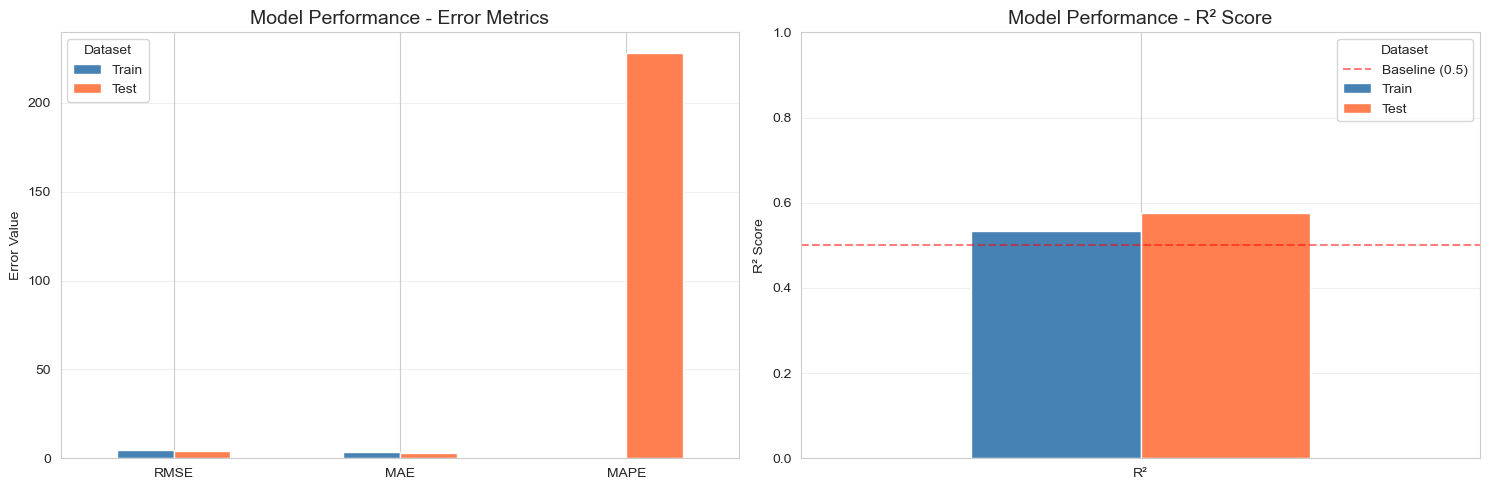

In [11]:
# 성능 비교 시각화
metrics_df = pd.DataFrame({
    'Train': [train_metrics['RMSE'], train_metrics['MAE'], train_metrics['R2'], train_metrics['MAPE']],
    'Test': [test_metrics['RMSE'], test_metrics['MAE'], test_metrics['R2'], test_metrics['MAPE']]
}, index=['RMSE', 'MAE', 'R²', 'MAPE'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 절대 지표 (RMSE, MAE, MAPE)
metrics_df.loc[['RMSE', 'MAE', 'MAPE']].plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Model Performance - Error Metrics', fontsize=14)
axes[0].set_ylabel('Error Value')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Dataset')
axes[0].grid(True, alpha=0.3, axis='y')

# R² Score
metrics_df.loc[['R²']].plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'])
axes[1].set_title('Model Performance - R² Score', fontsize=14)
axes[1].set_ylabel('R² Score')
axes[1].set_ylim([0, 1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Baseline (0.5)')
axes[1].legend(title='Dataset')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 9. Feature Importance (회귀 계수)

=== Linear Regression Coefficients ===
            Feature   Coefficient  Abs_Coefficient
2   avg_temperature -5.465489e+00     5.465489e+00
0   max_temperature  2.534002e+00     2.534002e+00
1   min_temperature -1.344386e+00     1.344386e+00
7             Goats -1.254534e+00     1.254534e+00
4             Cattl -1.174587e+00     1.174587e+00
11     rate_landuse  8.500237e-01     8.500237e-01
9             Sheep  6.964159e-01     6.964159e-01
8             Horse -3.982995e-01     3.982995e-01
5             Chick -2.373454e-01     2.373454e-01
10            Swine -1.728343e-01     1.728343e-01
6             Ducks  1.030694e-01     1.030694e-01
3             Buffa  2.220446e-16     2.220446e-16


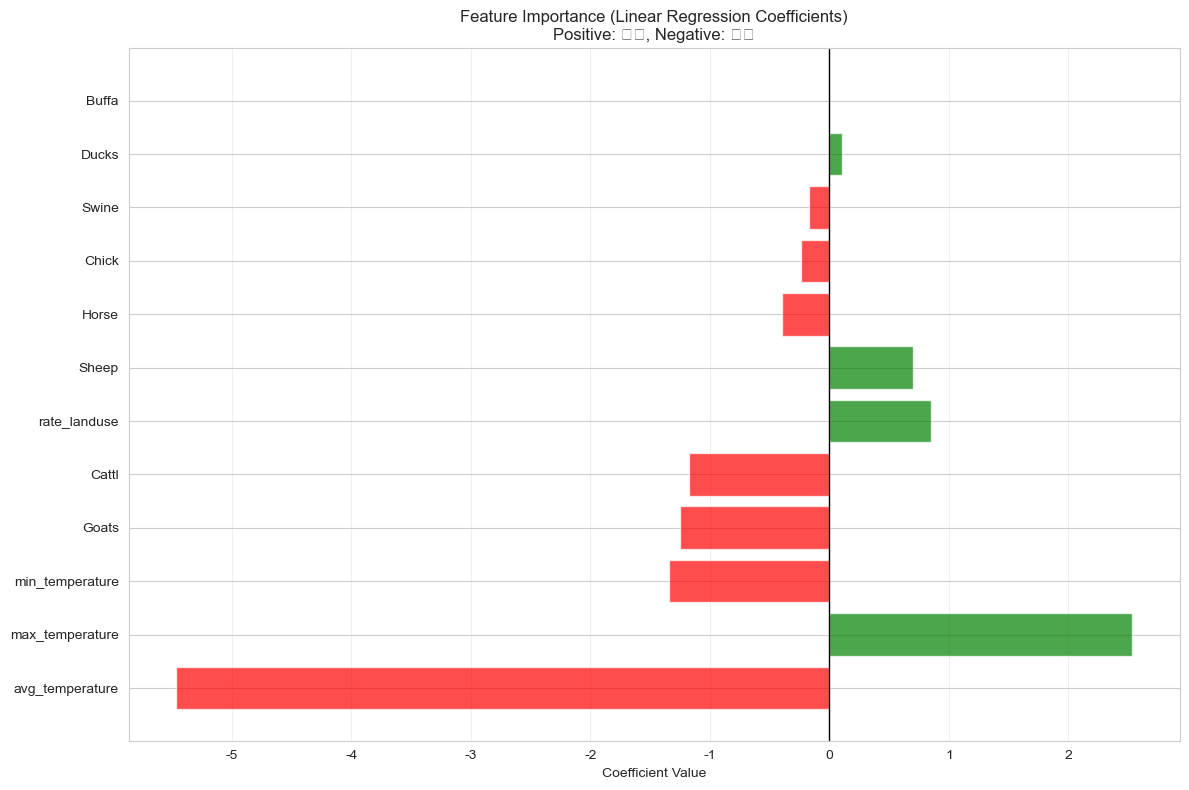

In [15]:
# 회귀 계수 분석
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_,
    'Abs_Coefficient': np.abs(lr_model.coef_)
}).sort_values('Abs_Coefficient', ascending=False)

print("=== Linear Regression Coefficients ===")
print(coefficients)

# 시각화
plt.figure(figsize=(12, 8))
colors = ['green' if x > 0 else 'red' for x in coefficients['Coefficient']]
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors, alpha=0.7)
plt.xlabel('Coefficient Value')
plt.title('Feature Importance (Linear Regression Coefficients)\nPositive: 증가, Negative: 감소')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

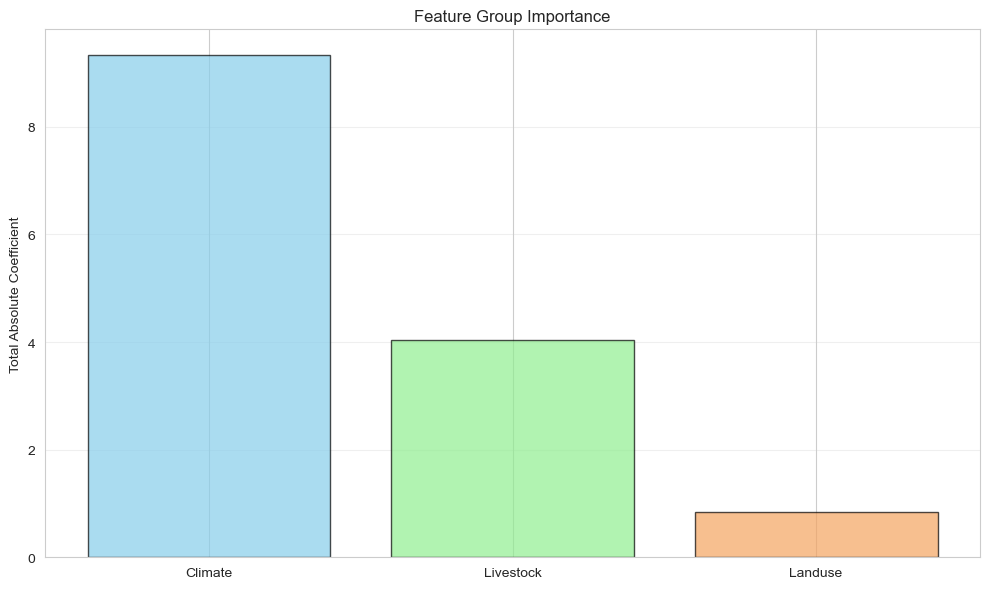


=== Feature Group Importance ===
       Group  Total_Abs_Coefficient
0    Climate               9.343878
1  Livestock               4.037086
2    Landuse               0.850024


In [16]:
# Feature 그룹별 중요도
climate_importance = coefficients[coefficients['Feature'].isin(climate_cols)]['Abs_Coefficient'].sum()
livestock_importance = coefficients[coefficients['Feature'].isin(livestock_cols)]['Abs_Coefficient'].sum()
landuse_importance = coefficients[coefficients['Feature'].isin(landuse_cols)]['Abs_Coefficient'].sum()

group_importance = pd.DataFrame({
    'Group': ['Climate', 'Livestock', 'Landuse'],
    'Total_Abs_Coefficient': [climate_importance, livestock_importance, landuse_importance]
}).sort_values('Total_Abs_Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(group_importance['Group'], group_importance['Total_Abs_Coefficient'], 
        color=['skyblue', 'lightgreen', 'sandybrown'], alpha=0.7, edgecolor='black')
plt.ylabel('Total Absolute Coefficient')
plt.title('Feature Group Importance')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\n=== Feature Group Importance ===")
print(group_importance)

## 10. 결과 요약

In [19]:
print("="*80)
print("Linear Regression 모델 결과 요약")
print("="*80)

print(f"\n1. 모델 성능:")
print(f"   Train - R²: {train_metrics['R2']:.4f}, RMSE: {train_metrics['RMSE']:.4f}")
print(f"   Test  - R²: {test_metrics['R2']:.4f}, RMSE: {test_metrics['RMSE']:.4f}")

print(f"\n2. Top 5 중요 Features (절댓값 기준):")
for i, row in coefficients.head(5).iterrows():
    direction = "↑" if row['Coefficient'] > 0 else "↓"
    print(f"   {direction} {row['Feature']}: {row['Coefficient']:.4f}")

print(f"\n3. Overfitting 확인:")
r2_diff = train_metrics['R2'] - test_metrics['R2']
if r2_diff < 0.05:
    print(f"   ✓ 양호 (Train-Test R² 차이: {r2_diff:.4f})")
elif r2_diff < 0.15:
    print(f"   ⚠ 주의 (Train-Test R² 차이: {r2_diff:.4f})")
else:
    print(f"   ✗ Overfitting 가능성 (Train-Test R² 차이: {r2_diff:.4f})")

Linear Regression 모델 결과 요약

1. 모델 성능:
   Train - R²: 0.5324, RMSE: 4.5793
   Test  - R²: 0.5754, RMSE: 4.0031

2. Top 5 중요 Features (절댓값 기준):
   ↓ avg_temperature: -5.4655
   ↑ max_temperature: 2.5340
   ↓ min_temperature: -1.3444
   ↓ Goats: -1.2545
   ↓ Cattl: -1.1746

3. Overfitting 확인:
   ✓ 양호 (Train-Test R² 차이: -0.0430)
